# 1. Introduction


## 1. Примеры применения ML в жизни

| № | Пример | Применение | Преимущество |
|---|--------|-----------|-------------|
| 1 | **Рекомендательные системы** (YouTube, Netflix) | Анализ истории просмотров пользователя | Экономие времени, увеличение продаж|
| 2 | **Фильтрация спама** (Email) | Классификация писем на спам/не спам | Автоматизация, защита от нежелательного контента, экономия времени |
| 3 | **Медицинская диагностика** | Анализ снимков, анализов крови для выявления болезней | Ускорение диагностики, объективность, помощь врачам |
| 4 | **Автономные автомобили** | Распознавание объектов и принятие решений | Безопасность, снижение количества аварий, снижение человеческого фактора |
| 5 | **Определение мошенничества** (Банки) | Анализ паттернов транзакций | Защита клиентов, предотвращение убытков, быстрое выявление аномалий |

## 2. Классификация задач (Supervised/Unsupervised)

### Задачи из таблицы курса:

| № задачи | Задача | Тип |
|---|--------|------|
| 1 | Предсказание цены дома | **Supervised - Regression** |
| 2 | Будет ли клиент возвращать кредит | **Supervised - Classification (Binary)** |
| 3 | Когда пациенту нужно лекарство | **Supervised - Classification** |
| 4 | Какое лечение выбрать | **Supervised - Classification (Multiclass)** |
| 5 | Выбор сегмента клиентов для промо | **Unsupervised - Clustering** |
| 6 | Распознавание дефектных продуктов | **Supervised - Classification (Binary)** |
| 7 | Размещение товаров на полке | **Unsupervised - Association** |
| 8 | Поиск сайтов по запросу | **Supervised - Ranking** |
| 9 | Сегментация клиентов | **Unsupervised - Clustering** |
| 10 | Обнаружение аномалий в трафике | **Unsupervised - Anomaly Detection** |

### Мои 5 примеров:

1. **Рекомендация товаров** → Supervised - Regression and Ranking
2. **Фильтрация спама** → Supervised - Classification (Binary)
3. **Медицинская диагностика** → Supervised - Classification (Multiclass)
4. **Автономные автомобили** → Supervised - Classification / Detection + Computer Vision
5. **Обнаружение мошенничества** → Unsupervised - Anomaly Detection + Supervised - Classification

## 3. Разница между Multiclass и Multilabel

### Multiclass (Мультиклассовая классификация):

- **Определение**: Каждый объект принадлежит **ОДНОМУ из нескольких классов**
- Классы **взаимоисключающие**

### Multilabel (Мультилейбл классификация):
- **Определение**: Каждый объект может принадлежать **НЕСКОЛЬКИМ классам одновременно**
- Классы **НЕ взаимоисключающие** (независимые)


## 4. Проблема предсказания цены жилья

### Вопрос: Классификация или Регрессия?

**Ответ**: **Регрессия**

### Можно ли свести регрессию к классификации?

**Ответ**: **ДА, но с потерей информации** (дешевая/дорогая квартира по пороговому значению)

# 2. Introduction to Data Analysis

In [269]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import scipy
import statsmodels
import lightgbm
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

In [270]:
df = pd.read_json("./data/train.json")

In [271]:
df.shape

(49352, 15)

In [272]:
df.columns # Target is price

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')

In [273]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [274]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [275]:
df.corr(numeric_only=True) # There no empty columns

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


In [276]:
df = df.loc[:, ["bathrooms", "bedrooms", "interest_level", "price"]]
df.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


# 3. Statistical Data Analysis

## 3. Target Analysis

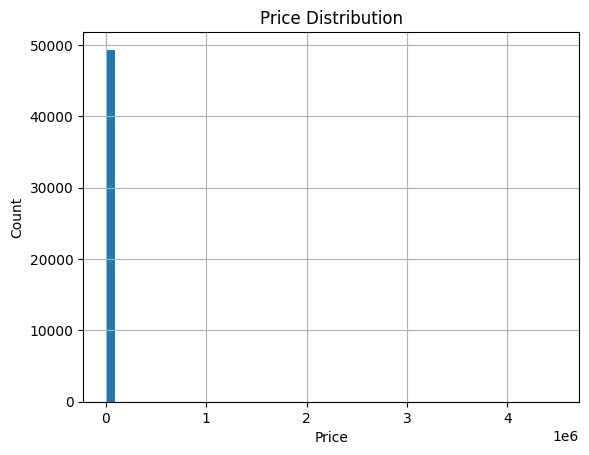

In [277]:
df["price"].hist(bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()
# Distribution is heavily right-skewed with extreme outliers (max ~4.5M)

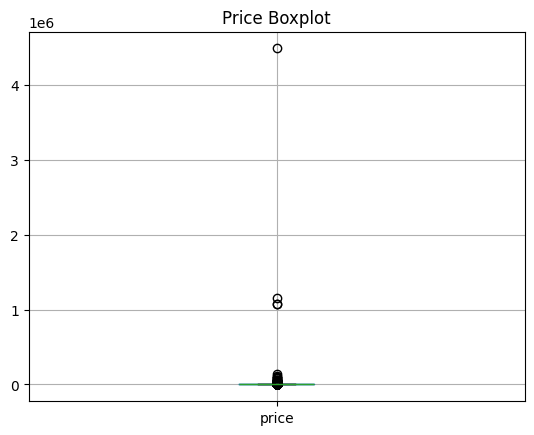

In [ ]:
df.boxplot(column="price")
plt.title("Price Boxplot")
plt.show()

In [279]:
p1, p99 = df["price"].quantile([0.01, 0.99])
df = df[df["price"].between(p1, p99)]
df.shape

(48379, 4)

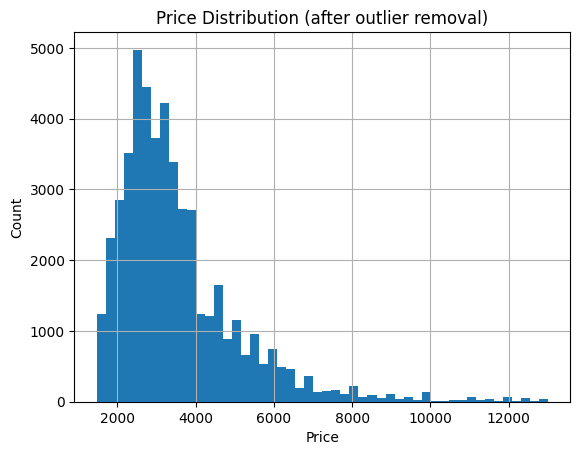

In [280]:
df["price"].hist(bins=50)
plt.title("Price Distribution (after outlier removal)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()
# Distribution is now closer to normal/slightly right-skewed, concentrated between ~1000 and ~8000

## 4. Characteristics Analysis

In [281]:
df["interest_level"].dtype # object (categorical string)

dtype('O')

In [282]:
df["interest_level"].value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

In [283]:
df["interest_level"] = df["interest_level"].map({"low": 0, "medium": 1, "high": 2})
df.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,1,2400
6,1.0,2,0,3800
9,1.0,2,1,3495
10,1.5,3,1,3000
15,1.0,0,0,2795


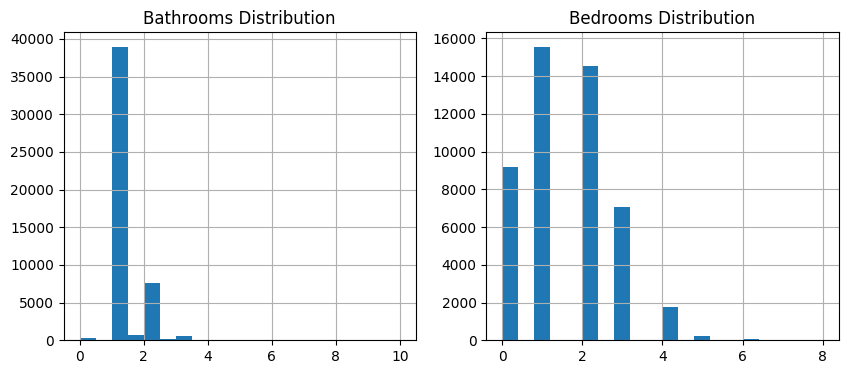

In [284]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["bathrooms"].hist(bins=20, ax=axes[0])
axes[0].set_title("Bathrooms Distribution")
df["bedrooms"].hist(bins=20, ax=axes[1])
axes[1].set_title("Bedrooms Distribution")
plt.show()
# Both are right-skewed. Bathrooms: outliers around 5+. Bedrooms: outliers at 6+

## 5. Complex Analysis

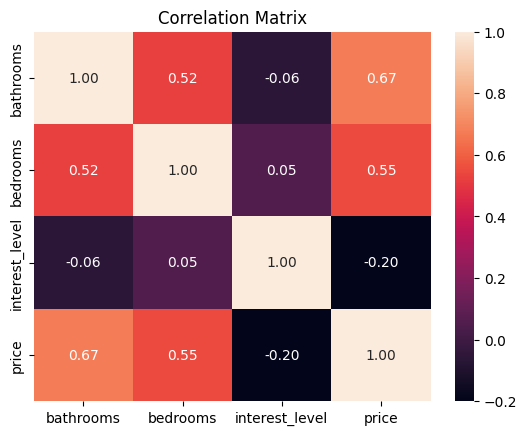

In [285]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()
# Weak correlations with price overall. bathrooms and bedrooms are moderately correlated with each other (0.53)

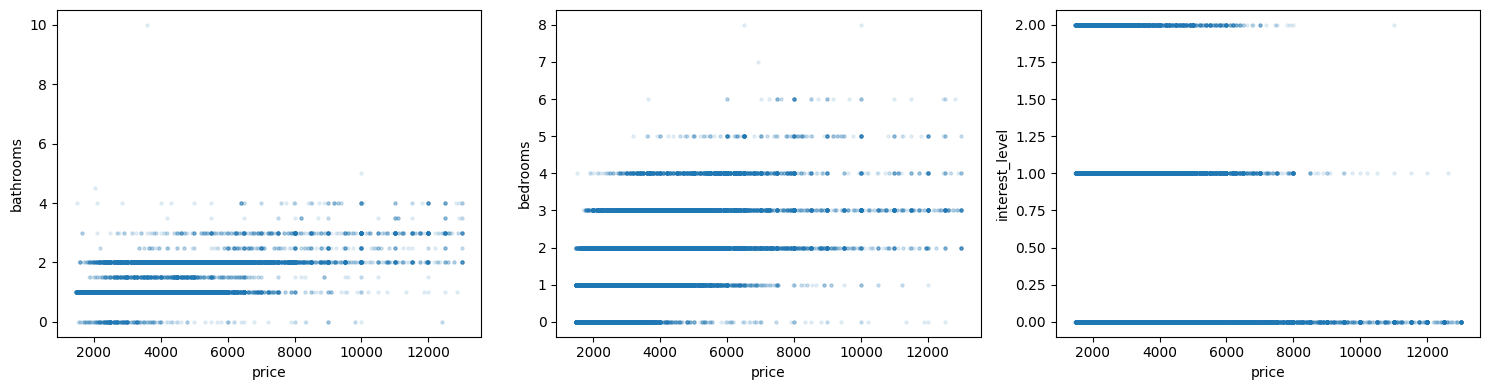

In [286]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feature in zip(axes, ["bathrooms", "bedrooms", "interest_level"]):
    ax.scatter(df["price"], df[feature], alpha=0.1, s=5)
    ax.set_xlabel("price")
    ax.set_ylabel(feature)
plt.tight_layout()
plt.show()
# All 3 features show weak correlation with price — slight upward trend for bathrooms and bedrooms

# 4. Creating Features

## 1. Squared Features

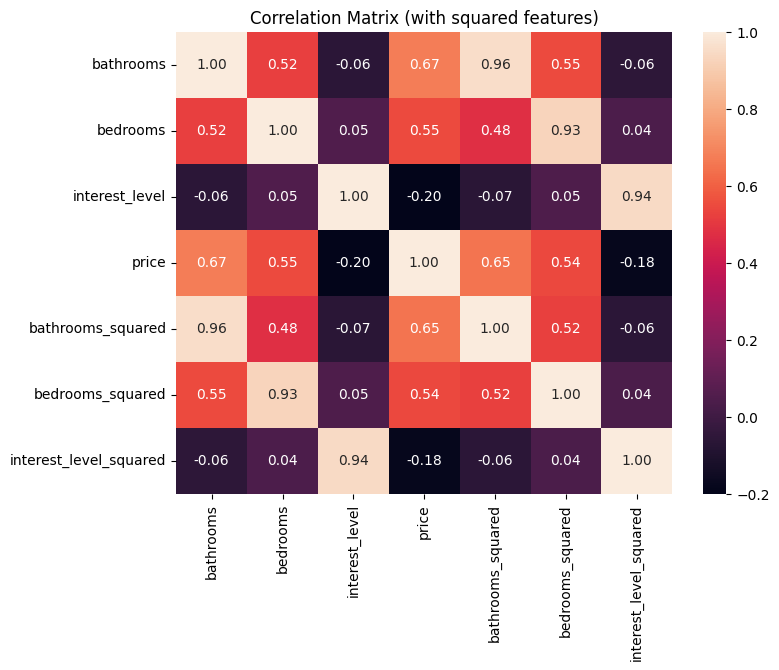

In [287]:
df["bathrooms_squared"] = df["bathrooms"] ** 2
df["bedrooms_squared"] = df["bedrooms"] ** 2
df["interest_level_squared"] = df["interest_level"] ** 2

corr_new = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_new, annot=True, fmt=".2f")
plt.title("Correlation Matrix (with squared features)")
plt.show()
# Squared features doesn't show higher correlation with price than basic features

## 2. Features for Training

In [288]:
X = df[["bathrooms", "bedrooms"]]
y = df["price"]

## 3-4. Train/Test Split + PolynomialFeatures

In [289]:
test_data = pd.read_json("./data/test.json")
test_data = test_data.loc[:, ["bathrooms", "bedrooms", "price"]]
test_data.head()

,bathrooms,bedrooms,price
0,1.0,1,2950
1,1.0,2,2850
2,1.0,0,2295
3,1.0,2,2900
5,1.0,1,3254


In [290]:
test_data = test_data[test_data["price"].between(p1, p99)]
print(f"Test data after outlier removal: {test_data.shape}")

Test data after outlier removal: (73255, 3)


In [291]:
X_train, y_train = X, y
X_test, y_test = test_data[["bathrooms", "bedrooms"]], test_data["price"]



In [292]:
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (48379, 2), Test: (73255, 2)


## 5-6. PolynomialFeatures (degree=10)

In [293]:
poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Original features: {X_train.shape[1]}")
print(f"Polynomial features: {X_train_poly.shape[1]}")
print(f"Feature names: {poly.get_feature_names_out()}")

Original features: 2
Polynomial features: 66
Feature names: ['1' 'bathrooms' 'bedrooms' 'bathrooms^2' 'bathrooms bedrooms'
 'bedrooms^2' 'bathrooms^3' 'bathrooms^2 bedrooms' 'bathrooms bedrooms^2'
 'bedrooms^3' 'bathrooms^4' 'bathrooms^3 bedrooms'
 'bathrooms^2 bedrooms^2' 'bathrooms bedrooms^3' 'bedrooms^4'
 'bathrooms^5' 'bathrooms^4 bedrooms' 'bathrooms^3 bedrooms^2'
 'bathrooms^2 bedrooms^3' 'bathrooms bedrooms^4' 'bedrooms^5'
 'bathrooms^6' 'bathrooms^5 bedrooms' 'bathrooms^4 bedrooms^2'
 'bathrooms^3 bedrooms^3' 'bathrooms^2 bedrooms^4' 'bathrooms bedrooms^5'
 'bedrooms^6' 'bathrooms^7' 'bathrooms^6 bedrooms'
 'bathrooms^5 bedrooms^2' 'bathrooms^4 bedrooms^3'
 'bathrooms^3 bedrooms^4' 'bathrooms^2 bedrooms^5' 'bathrooms bedrooms^6'
 'bedrooms^7' 'bathrooms^8' 'bathrooms^7 bedrooms'
 'bathrooms^6 bedrooms^2' 'bathrooms^5 bedrooms^3'
 'bathrooms^4 bedrooms^4' 'bathrooms^3 bedrooms^5'
 'bathrooms^2 bedrooms^6' 'bathrooms bedrooms^7' 'bedrooms^8'
 'bathrooms^9' 'bathrooms^8 bedrooms'

# 5. Training Models

## 1. Results Table

In [294]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

result_MAE = pd.DataFrame(columns=["model", "train", "test"])
result_RMSE = pd.DataFrame(columns=["model", "train", "test"])

## 2. Linear Regression

In [295]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

In [296]:
lr_mae_train = mean_absolute_error(y_train, y_train_pred_lr)
lr_mae_test = mean_absolute_error(y_test, y_test_pred_lr)
print(f"Linear Regression MAE — Train: {lr_mae_train:.2f}, Test: {lr_mae_test:.2f}")

lr_rmse_train = root_mean_squared_error(y_train, y_train_pred_lr)
lr_rmse_test = root_mean_squared_error(y_test, y_test_pred_lr)
print(f"Linear Regression RMSE — Train: {lr_rmse_train:.2f}, Test: {lr_rmse_test:.2f}")

Linear Regression MAE — Train: 784.56, Test: 790.80
Linear Regression RMSE — Train: 1123.88, Test: 1368.60


In [297]:
result_MAE.loc[len(result_MAE)] = ["linear_regression", lr_mae_train, lr_mae_test]
result_RMSE.loc[len(result_RMSE)] = ["linear_regression", lr_rmse_train, lr_rmse_test]

## 3. Decision Tree

In [298]:
dt = DecisionTreeRegressor(random_state=21)
dt.fit(X_train, y_train)

y_train_pred_dt = dt.predict(X_train)
y_test_pred_dt = dt.predict(X_test)

In [299]:
dt_mae_train = mean_absolute_error(y_train, y_train_pred_dt)
dt_mae_test = mean_absolute_error(y_test, y_test_pred_dt)
print(f"Decision Tree MAE — Train: {dt_mae_train:.2f}, Test: {dt_mae_test:.2f}")

dt_rmse_train = root_mean_squared_error(y_train, y_train_pred_dt)
dt_rmse_test = root_mean_squared_error(y_test, y_test_pred_dt)
print(f"Decision Tree RMSE — Train: {dt_rmse_train:.2f}, Test: {dt_rmse_test:.2f}")

Decision Tree MAE — Train: 756.04, Test: 759.61
Decision Tree RMSE — Train: 1077.48, Test: 1081.24


In [300]:
result_MAE.loc[len(result_MAE)] = ["decision_tree", dt_mae_train, dt_mae_test]
result_RMSE.loc[len(result_RMSE)] = ["decision_tree", dt_rmse_train, dt_rmse_test]

## 4. Naive Models

In [301]:
train_mean = y_train.mean()
train_median = y_train.median()

y_train_pred_mean = np.full(len(y_train), train_mean)
y_train_pred_median = np.full(len(y_train), train_median)
y_test_pred_mean = np.full(len(y_test), train_mean)
y_test_pred_median = np.full(len(y_test), train_median)

print(f"Train mean: {train_mean:.2f}, Train median: {train_median:.2f}")

Train mean: 3538.64, Train median: 3150.00


In [302]:
# MAE for naive models
mean_mae_train = mean_absolute_error(y_train, y_train_pred_mean)
mean_mae_test = mean_absolute_error(y_test, y_test_pred_mean)
median_mae_train = mean_absolute_error(y_train, y_train_pred_median)
median_mae_test = mean_absolute_error(y_test, y_test_pred_median)
print(f"Naive Mean MAE — Train: {mean_mae_train:.2f}, Test: {mean_mae_test:.2f}")
print(f"Naive Median MAE — Train: {median_mae_train:.2f}, Test: {median_mae_test:.2f}")

# RMSE for naive models
mean_rmse_train = root_mean_squared_error(y_train, y_train_pred_mean)
mean_rmse_test = root_mean_squared_error(y_test, y_test_pred_mean)
median_rmse_train = root_mean_squared_error(y_train, y_train_pred_median)
median_rmse_test = root_mean_squared_error(y_test, y_test_pred_median)
print(f"Naive Mean RMSE — Train: {mean_rmse_train:.2f}, Test: {mean_rmse_test:.2f}")
print(f"Naive Median RMSE — Train: {median_rmse_train:.2f}, Test: {median_rmse_test:.2f}")

Naive Mean MAE — Train: 1139.19, Test: 1137.83
Naive Median MAE — Train: 1086.21, Test: 1084.59
Naive Mean RMSE — Train: 1597.65, Test: 1590.39
Naive Median RMSE — Train: 1644.24, Test: 1635.40


In [303]:
result_MAE.loc[len(result_MAE)] = ["naive_mean", mean_mae_train, mean_mae_test]
result_MAE.loc[len(result_MAE)] = ["naive_median", median_mae_train, median_mae_test]
result_RMSE.loc[len(result_RMSE)] = ["naive_mean", mean_rmse_train, mean_rmse_test]
result_RMSE.loc[len(result_RMSE)] = ["naive_median", median_rmse_train, median_rmse_test]

## 5. Compare Results

In [304]:
print("=== MAE ===")
print(result_MAE.to_string(index=False))
print()
print("=== RMSE ===")
print(result_RMSE.to_string(index=False))

=== MAE ===
            model       train        test
linear_regression  784.563837  790.798082
    decision_tree  756.044735  759.614776
       naive_mean 1139.192515 1137.831965
     naive_median 1086.210505 1084.587987

=== RMSE ===
            model       train        test
linear_regression 1123.877748 1368.601428
    decision_tree 1077.483596 1081.242292
       naive_mean 1597.646655 1590.391201
     naive_median 1644.236439 1635.396216


### Какая модель лучше?

**Decision Tree** показывает лучшие результаты по обеим метрикам (MAE: 759.61, RMSE: 1081.24 на тесте). Linear Regression чуть хуже (MAE: 790.80, RMSE: 1368.60). Naive модели значительно уступают — они не учитывают признаки и служат лишь baseline.